In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 100

cgpa = np.round(np.random.uniform(5.5, 9.5, n), 2)
iq = np.random.randint(90, 141, n)
internships = np.random.randint(0, 4, n)
projects = np.random.randint(1, 6, n)

# Generate package with some realistic relationship + random noise
package = (
    0.8 * cgpa
    + 0.025 * iq
    + 0.35 * internships
    + 0.25 * projects
    - 4.5
    + np.random.normal(0, 0.4, n)
)

package = np.round(package, 2)

df = pd.DataFrame({
    'cgpa': cgpa,
    'iq': iq,
    'internships': internships,
    'projects': projects,
    'package': package
})

df.head()

,cgpa,iq,internships,projects,package
0,7.00,121,3,3,5.88
1,9.30,128,3,1,7.25
2,8.43,138,2,1,7.28
3,7.89,121,3,4,6.71
4,6.12,93,2,3,3.88


In [3]:
df.shape

(100, 5)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   cgpa         100 non-null    float64
 1   iq           100 non-null    int32  
 2   internships  100 non-null    int32  
 3   projects     100 non-null    int32  
 4   package      100 non-null    float64
dtypes: float64(2), int32(3)
memory usage: 2.9 KB


In [5]:
X = df[['cgpa', 'iq', 'internships', 'projects']]
y = df['package']

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
X_train.shape

(80, 4)

In [8]:
X_test.shape

(20, 4)

In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [10]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
model.coef_

array([0.77991991, 0.02963836, 0.3328414 , 0.26378065])

In [13]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

In [14]:
coefficients

,Feature,Coefficient
0,cgpa,0.779920
1,iq,0.029638
2,internships,0.332841
3,projects,0.263781


In [15]:
y_pred = model.predict(X_test)

In [16]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

In [17]:
comparison

,Actual,Predicted
0,3.90,4.008973
1,6.35,6.770012
2,6.89,6.453947
3,5.32,5.790976
4,4.46,4.703955
5,4.75,4.880485
6,5.77,5.608545
7,5.97,6.494647
8,4.07,4.133062
9,5.88,6.008181


In [18]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.3071584926435088
MSE : 0.15082117411745935
RMSE: 0.38835701888527696
R²  : 0.92493406878122


In [19]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -4.827366677675943
Coefficients: [0.77991991 0.02963836 0.3328414  0.26378065]


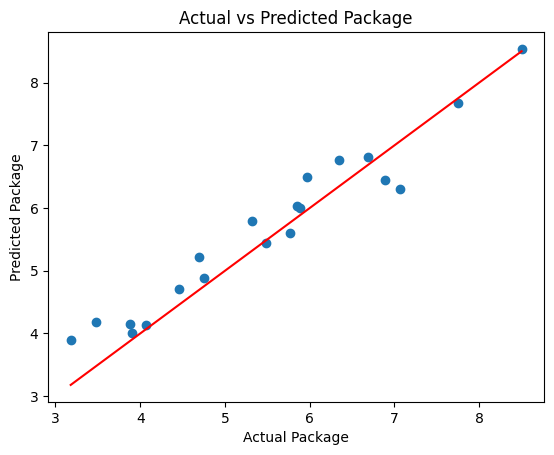

In [20]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel('Actual Package')
plt.ylabel('Predicted Package')
plt.title('Actual vs Predicted Package')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

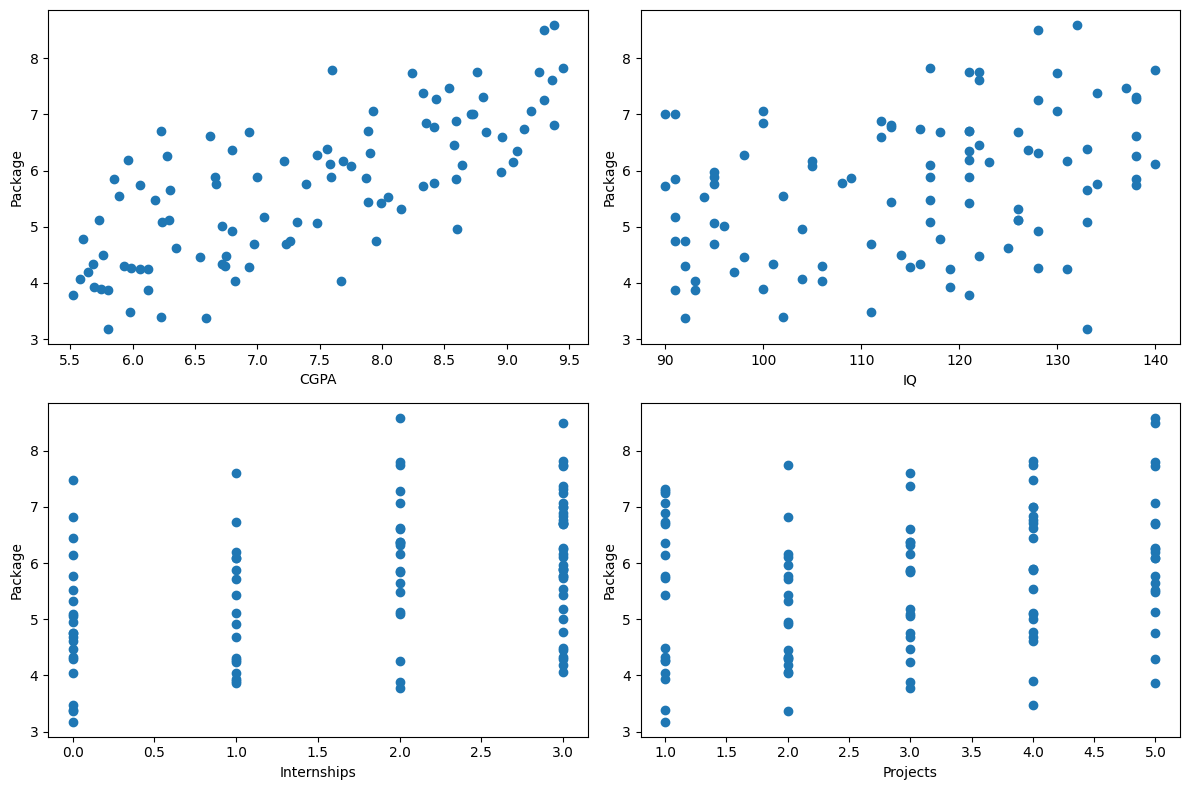

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].scatter(df['cgpa'], df['package'])
axes[0, 0].set_xlabel('CGPA')
axes[0, 0].set_ylabel('Package')

axes[0, 1].scatter(df['iq'], df['package'])
axes[0, 1].set_xlabel('IQ')
axes[0, 1].set_ylabel('Package')

axes[1, 0].scatter(df['internships'], df['package'])
axes[1, 0].set_xlabel('Internships')
axes[1, 0].set_ylabel('Package')

axes[1, 1].scatter(df['projects'], df['package'])
axes[1, 1].set_xlabel('Projects')
axes[1, 1].set_ylabel('Package')

plt.tight_layout()
plt.show()